In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
## este paquete me permite implementar un modelo de clasificacion de arbol de decision

from sklearn.model_selection import train_test_split
## este paquete me permite dividir los datos en entrenamiento y testeo

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
## estos son los paquetes basicos para medir el desempeño del modelo

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
## estos son metricas especificas del modelo y me van a servir para la poda

import graphviz
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
## Estos paquetes me van a permitir hacer la grafica del arbol


### Voy a bajar paquetes que me permiten hacer la poda

from sklearn.model_selection import RandomizedSearchCV
### Este me permite hacer busquedas de parametros que son un numero continuo
from sklearn.model_selection import GridSearchCV
### Este me permite hacer busquedas de numeros enteros
from scipy.stats import loguniform
#Me permite hacer una distribucion uniforme de una variable

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
base=pd.read_excel("/content/drive/MyDrive/Semestre 8/Analitica de negocios/Datos_Conitnue_Edu.xlsx")

Mounted at /content/drive


In [ ]:
#Limpieza de datos
base.isnull().sum() #No hay vacios
base.duplicated().sum()
# hay 14 datos duplicados
duplicados = base[base.duplicated(keep=False)]
duplicados
#ELIMINANDO DUPLICADOS
base2 = base.drop_duplicates()
base2.duplicated().sum()

np.int64(0)

 realice un modelo tipo Árboles de decisión que se usará para predecir
si una persona está interesada o no en un curso de educación continua, según todas las
demás variables en la base de datos; para eso siga los siguientes parámetros:

In [ ]:
#Punto B
y=base2['ContinueEdu']
base2.columns
x=base2[['Age','Marriage','Income','Edu','Own','Pet','City']]
# Voy a dividir los datos en entrenamiento y testeo (primero va el entrenamiento luego el testeo, primero x luego y - orden importa)
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.75,random_state=42)
x_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1489 entries, 170 to 1131
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Age       1489 non-null   int64
 1   Marriage  1489 non-null   int64
 2   Income    1489 non-null   int64
 3   Edu       1489 non-null   int64
 4   Own       1489 non-null   int64
 5   Pet       1489 non-null   int64
 6   City      1489 non-null   int64
dtypes: int64(7)
memory usage: 93.1 KB


In [ ]:
#Punto C
## Definir el modelo
dt=DecisionTreeClassifier(criterion="gini",max_depth=4,random_state=42)

##entrenar el modelo
dt.fit(x_train,y_train)

## Prediccion con datos fuera de muestra
y_pred=dt.predict(x_test)


**Punto 4 Y 5**

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       439
           1       0.96      0.76      0.85        58

    accuracy                           0.97       497
   macro avg       0.96      0.88      0.91       497
weighted avg       0.97      0.97      0.97       497



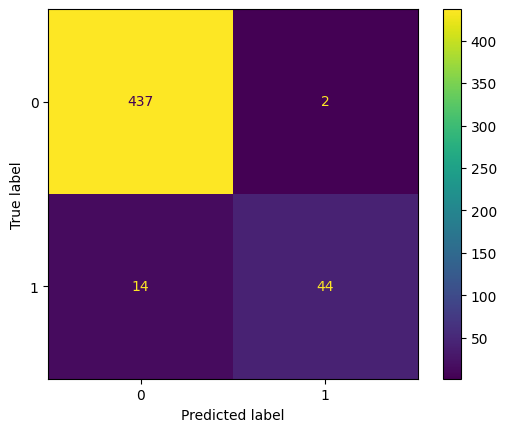

In [ ]:
### Metricas de medicion

### Matriz de confusión
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),display_labels=dt.classes_).plot()

#reporte de clasificacion
print(classification_report(y_test,y_pred))

In [ ]:
#SOLUCION 4
# a. cuantas observaciones están bien clasificaras en 0: 437
# b. Cuantas observaciones están bien clasificadas como 1: 44
# c. cuantas observaciones el modelo clasificó como 0 pero en realidad son 1: 14
# d. Cuantas observaciones el modelo clasificó como 1 pero en realidad son 0: 2

In [ ]:
#SOLUCION 5
# El modelo presenta un rendimiento sobresaliente.
# La precisión es muy alta para ambas clases (0.96–0.97),
#lo que indica que rara vez se equivoca cuando clasifica.
# El recall es perfecto para la clase 0 (1.00) y bueno para la clase 1 (0.76),
# mostrando que el modelo ahora detecta correctamente a la mayoría de los interesados.
# El F1-score es de 0.98 para la clase 0 y 0.85 para la clase 1, evidenciando un equilibrio adecuado
# entre precisión y recall. Finalmente, la accuracy global de 0.97 confirma un desempeño general muy sólido.


**Punto 6: grafica arbol** **texto en negrita**

In [ ]:
## Graficar el arbol

## voy a sacar el nombre de las variables que estan en x para luego usarlas en la grafica
nv=list(x.columns.values)
nv

## voy a sacar el nombre de las categorias de las variables Y en un string que eran "yes" and "no"
categorias=[str(name) for name in dt.classes_]
categorias

### las decisiones con las que funciona el modelo estan guardades en el modelo que defini,
# tengo que pasar esas reglas de decision a puntos de datos
dot_data=export_graphviz(dt,feature_names=nv,class_names=categorias)

## voy a ver la grafica
graphviz.Source(dot_data)

##vamos a exportar la grafica como imagen
gr_trees=graph_from_dot_data(dot_data)
gr_trees.write_png("grafica arbol.png")

True

**Punto 7** encuentre la hoja pura que tenga observaciones clasificadas en 0 y escriba la regla de
decisión

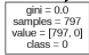

In [ ]:
# Regla de Decision
# Age: True --- Age <= 54
# Pet: True --- Pet <= 0.5
# Income: False --- Income > 108,500
# Income: True --- Income <= 136500

**Punto 8** Encuentre la hoja pura que tenga observaciones clasificadas en 1 y escriba la regla de
decisión

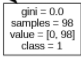

In [ ]:
#Regla de decision
# Income: False --- Income > 140000
# Edu: False --- Edu > 1.5
# Income: False --- Income > 136.500